In [1]:
!pip uninstall numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-2.0.2


In [ ]:
!pip uninstall numpy -y

In [1]:
!pip install numpy==1.23.5

In [ ]:
!pip uninstall pmdarima

Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/pmdarima-2.0.4.dist-info/*
    /usr/local/lib/python3.11/dist-packages/pmdarima/*
Proceed (Y/n)? y
  Successfully uninstalled pmdarima-2.0.4


In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 16.1 MB/s eta 0:00:00


In [3]:
import pmdarima as pm

In [4]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import product
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 7.5]
# read in data file
df = pd.read_csv('/content/jj.csv', index_col='date', parse_dates=True)
#df['date'] = pd.to_datetime(df['date'])
#df.set_index('date', inplace=True)
df.head()

,data
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61


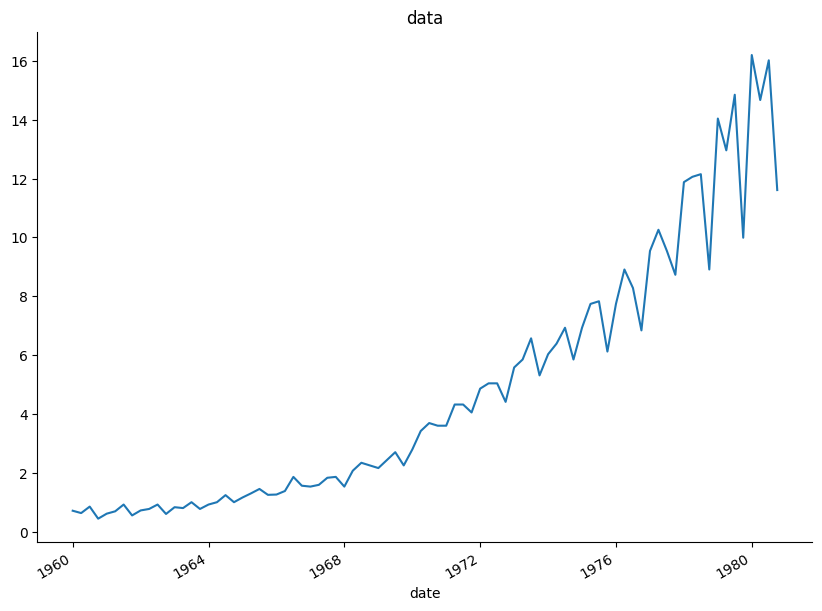

In [ ]:
# @title data

from matplotlib import pyplot as plt
df['data'].plot(kind='line', title='data')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 84 entries, 1960-01-01 to 1980-10-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    84 non-null     float64
dtypes: float64(1)
memory usage: 1.3 KB


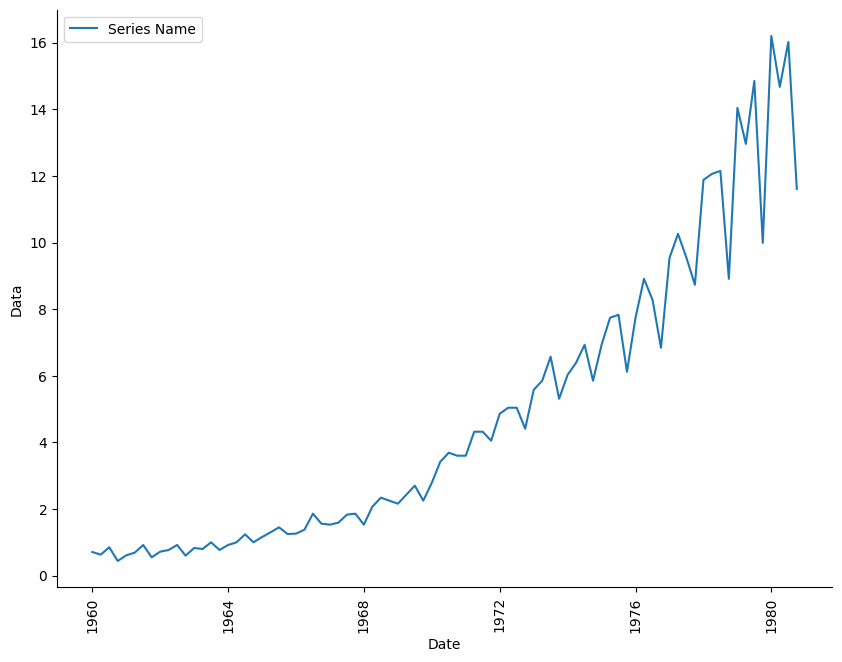

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

# Convert 'date' to datetime

def _plot_series(series, series_name):
    palette = list(sns.color_palette('Dark2'))
    xs = series.index  # Index will be the x-axis
    ys = series['data']
    plt.plot(xs, ys, label=series_name)


fig, ax = plt.subplots()
df_sorted = df.sort_index(ascending=True)
_plot_series(df_sorted, 'Series Name')

sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
plt.ylabel('Data')
plt.xticks(rotation=90)  # Rotate date labels vertically
plt.legend()
plt.show()

Test for Non-Stationarity

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['data'].dropna())
print('p-vlaue: ', result[1])

p-vlaue:  1.0


In [7]:
result = adfuller(df['data'].diff().dropna())
print('p-vlaue: ', result[1])

p-vlaue:  0.9088542416911305


In [8]:
result = adfuller(df['data'].diff().diff().dropna())
print('p-vlaue: ', result[1])

p-vlaue:  0.006051099869603682


In [9]:
# ADF test on original series
result = adfuller(df['data'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: 2.7420165734574744
p-value: 1.0
Critical Values: {'1%': -3.524624466842421, '5%': -2.9026070739026064, '10%': -2.5886785262345677}


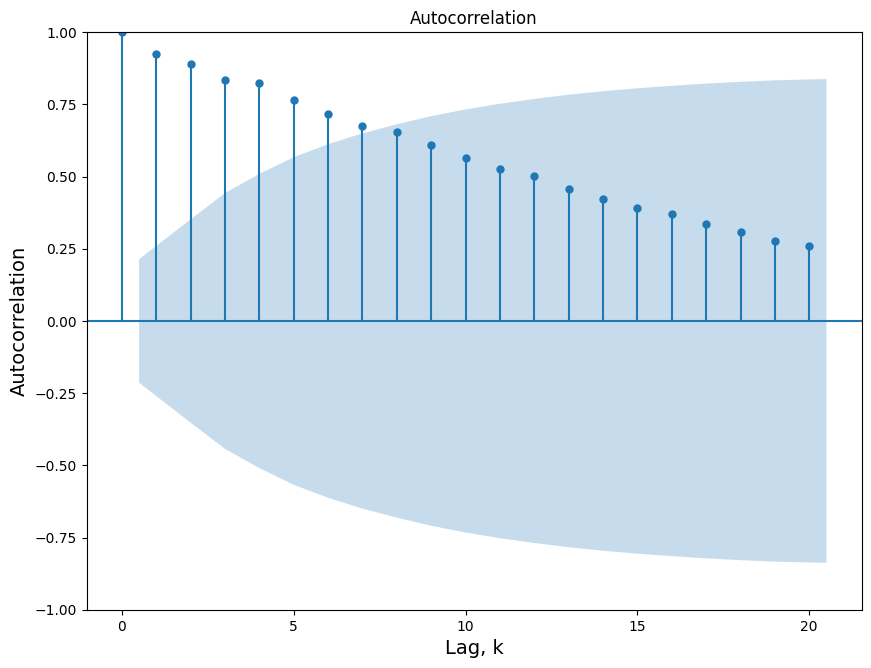

In [ ]:
#plot the autocorrelation function ACF

# Plot ACF
plot_acf(df['data'])
plt.xlabel('Lag, k', fontsize=14)
plt.ylabel('Autocorrelation', fontsize=14)
plt.show()

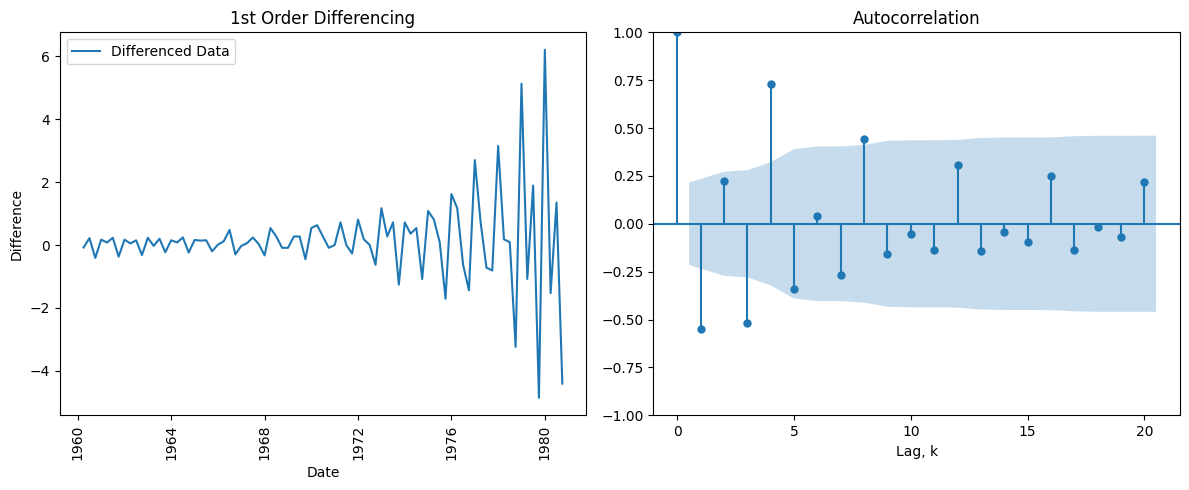

ADF Statistic (Differenced): -0.40740976363804615
p-value (Differenced): 0.9088542416911305
Critical Values (Differenced): {'1%': -3.524624466842421, '5%': -2.9026070739026064, '10%': -2.5886785262345677}


In [10]:
# Create figure with two subplots
f = plt.figure(figsize=(12, 5))  # Adjusted figure size for clarity

# Left subplot: 1st order differencing
ax1 = f.add_subplot(121)
ax1.set_title('1st Order Differencing')
ax1.plot( df['data'].diff(), label='Differenced Data')  # Use 'date' for x-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Difference')
ax1.tick_params(axis='x', rotation=90)  # Rotate x-axis labels
ax1.legend()

# Right subplot: ACF of differenced series
ax2 = f.add_subplot(122)
ax2.set_title('ACF of Differenced Series')
plot_acf(df['data'].diff().dropna(), ax=ax2)
ax2.set_xlabel('Lag, k')

# Adjust layout and display
plt.tight_layout()
plt.show()

# ADF test on differenced series
result_diff = adfuller(df['data'].diff().dropna())
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])
print('Critical Values (Differenced):', result_diff[4])


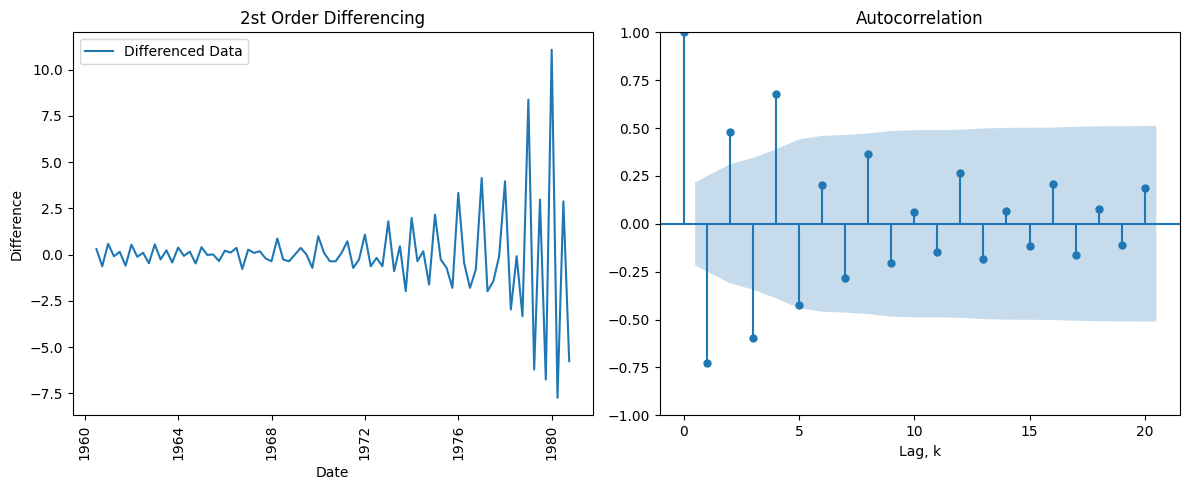

ADF Statistic (twice Differenced): -3.585162874793155
p-value (twice Differenced): 0.006051099869603682
Critical Values (twice Differenced): {'1%': -3.524624466842421, '5%': -2.9026070739026064, '10%': -2.5886785262345677}


In [11]:
# use the differencing operator twice
# Create figure with two subplots
f = plt.figure(figsize=(12, 5))  # Adjusted figure size for clarity

# Left subplot: 2st order differencing
ax1 = f.add_subplot(121)
ax1.set_title('2st Order Differencing')
ax1.plot( df['data'].diff().diff(), label='Differenced Data')  # Use 'date' for x-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Difference')
ax1.tick_params(axis='x', rotation=90)  # Rotate x-axis labels
ax1.legend()

# Right subplot: ACF of differenced series
ax2 = f.add_subplot(122)
ax2.set_title('ACF of Differenced Series')
plot_acf(df['data'].diff().diff().dropna(), ax=ax2)
ax2.set_xlabel('Lag, k')

# Adjust layout and display
plt.tight_layout()
plt.show()

# ADF test on differenced series
result_diff = adfuller(df['data'].diff().diff().dropna())
print('ADF Statistic (twice Differenced):', result_diff[0])
print('p-value (twice Differenced):', result_diff[1])
print('Critical Values (twice Differenced):', result_diff[4])

In [12]:
df_diff = df['data'].diff().diff().dropna()

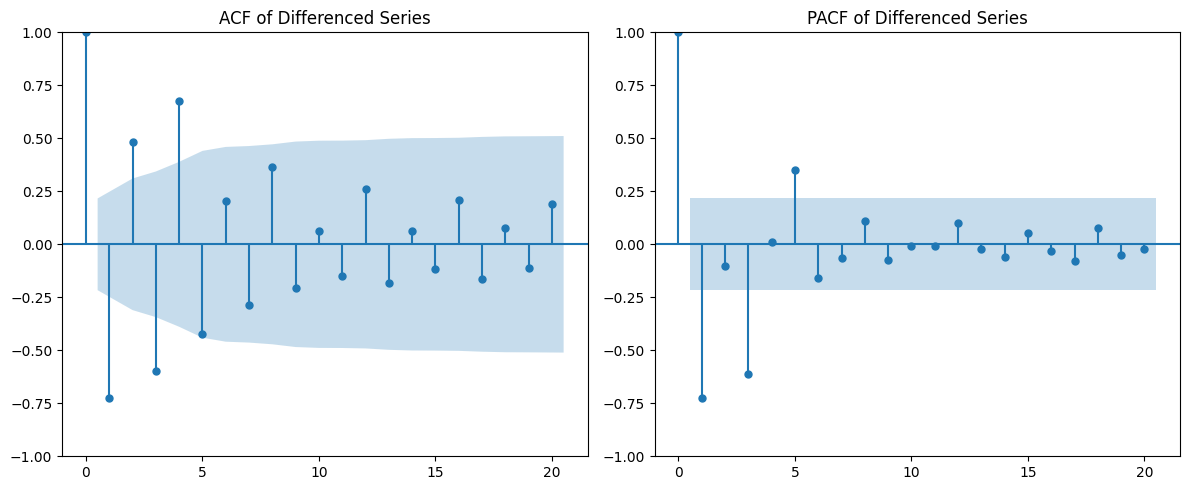

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF of differenced series
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df_diff, ax=ax1, title='ACF of Differenced Series')
plot_pacf(df_diff, ax=ax2, title='PACF of Differenced Series')
plt.tight_layout()
plt.show()

 Plot ACF and PACF to identify p and q

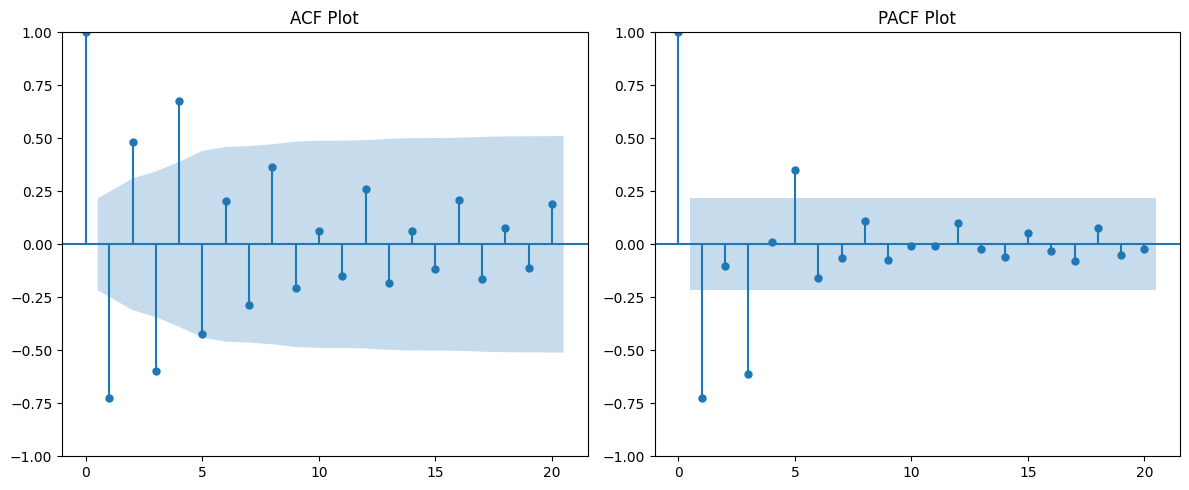

In [14]:

# 2nd order differenced(Twice) data
diff_data = df['data'].diff().diff().dropna()

plt.figure(figsize=(12, 5))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(diff_data, ax=plt.gca(), lags=20)
plt.title('ACF Plot')

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(diff_data, ax=plt.gca(), lags=20)
plt.title('PACF Plot')

plt.tight_layout()
plt.show()


In [15]:
from pmdarima import auto_arima

# Fit auto_arima model to find the best p, d, q
model = auto_arima(diff_data,
                   start_p=0, max_p=3,
                   start_q=0, max_q=3,
                   d=0,  # d is set to 0 since data is already differenced twice
                   seasonal=False,
                   trace=True,
                   error_action='ignore',
                   suppress_warnings=True,
                   stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=382.017, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=316.440, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=316.822, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=268.110, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=119.339, Time=0.23 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=119.504, Time=0.25 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=116.566, Time=0.30 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=118.070, Time=0.47 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=318.763, Time=0.06 sec
 ARIMA

In [16]:
# Use auto_arima to find the best p, d, q
model = pm.auto_arima(df['data'],
                      start_p=0, start_q=0,
                      max_p=3, max_q=3,
                      d=2,  # Let auto_arima determine d (should be 2)
                      seasonal=False,  # No strong seasonality visible
                      stepwise=True,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True)

# Print the best model
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=383.979, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=318.383, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=382.017, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=318.763, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=316.440, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=316.822, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=268.110, Time=0.09 sec
 ARIMA(3,2,1)(0,0,0)[0]             : AIC=119.339, Time=0.28 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(3,2,2)(0,0,0)[0]             : AIC=119.504, Time=0.27 sec
 ARIMA

**Test model performance**

Model Performance:
Mean Absolute Error (MAE):      0.3035
Mean Squared Error (MSE):       0.1857
Root Mean Squared Error (RMSE): 0.4309
R-squared (R² Score):           0.9899


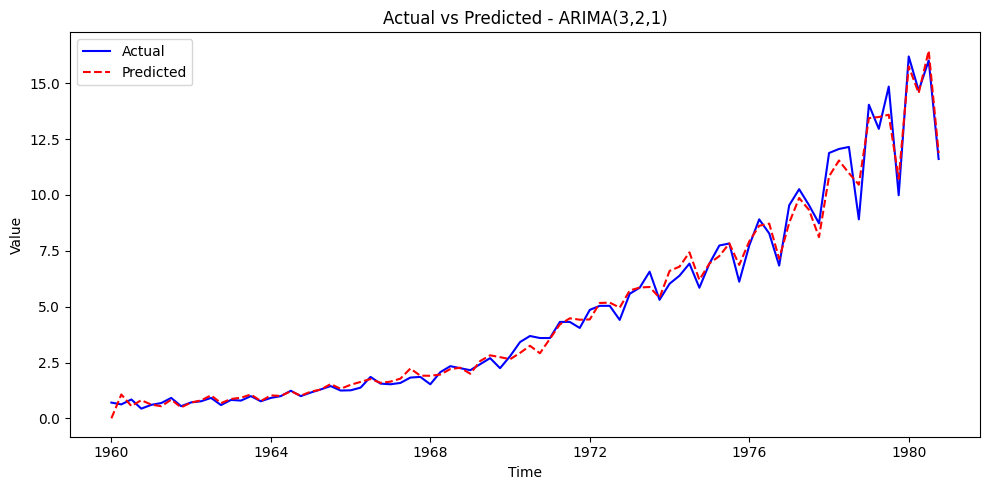

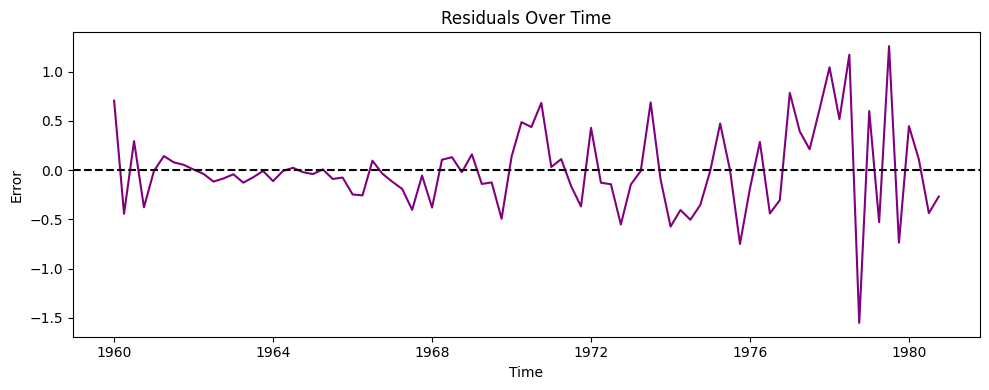

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Generate predictions (in-sample)
pred = model.predict_in_sample()

#Calculate residuals
residuals = df['data'].values - pred

#Evaluate with standard metrics
mse = mean_squared_error(df['data'], pred)
mae = mean_absolute_error(df['data'], pred)
rmse = np.sqrt(mse)
r2 = r2_score(df['data'], pred)

print("Model Performance:")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score):           {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(df['data'], label='Actual', color='blue')
plt.plot(pred, label='Predicted', color='red', linestyle='--')
plt.title("Actual vs Predicted - ARIMA(3,2,1)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

#Plot Residuals
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals', color='purple')
plt.axhline(y=0, linestyle='--', color='black')
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

**Forecast model 24 months into the future**

In [ ]:
df.index

DatetimeIndex(['1960-01-01', '1960-04-01', '1960-07-02', '1960-10-01',
               '1961-01-01', '1961-04-02', '1961-07-02', '1961-10-01',
               '1962-01-01', '1962-04-02', '1962-07-02', '1962-10-01',
               '1963-01-01', '1963-04-02', '1963-07-02', '1963-10-01',
               '1964-01-01', '1964-04-01', '1964-07-02', '1964-10-01',
               '1965-01-01', '1965-04-02', '1965-07-02', '1965-10-01',
               '1966-01-01', '1966-04-02', '1966-07-02', '1966-10-01',
               '1967-01-01', '1967-04-02', '1967-07-02', '1967-10-01',
               '1968-01-01', '1968-04-01', '1968-07-02', '1968-10-01',
               '1969-01-01', '1969-04-02', '1969-07-02', '1969-10-01',
               '1970-01-01', '1970-04-02', '1970-07-02', '1970-10-01',
               '1971-01-01', '1971-04-02', '1971-07-02', '1971-10-01',
               '1972-01-01', '1972-04-01', '1972-07-02', '1972-10-01',
               '1973-01-01', '1973-04-02', '1973-07-02', '1973-10-01',
      

In [19]:
df1 = df.copy()

In [ ]:
# 6 month SMA
df1['6-month-SMA'] = df1['data'].rolling(window=6).mean()

# 12 month SMA
df1['12-month-SMA'] = df1['data'].rolling(window=12).mean()

bool_series = df1.duplicated()

<Axes: title={'center': 'Simple Moving Averages'}, xlabel='date'>

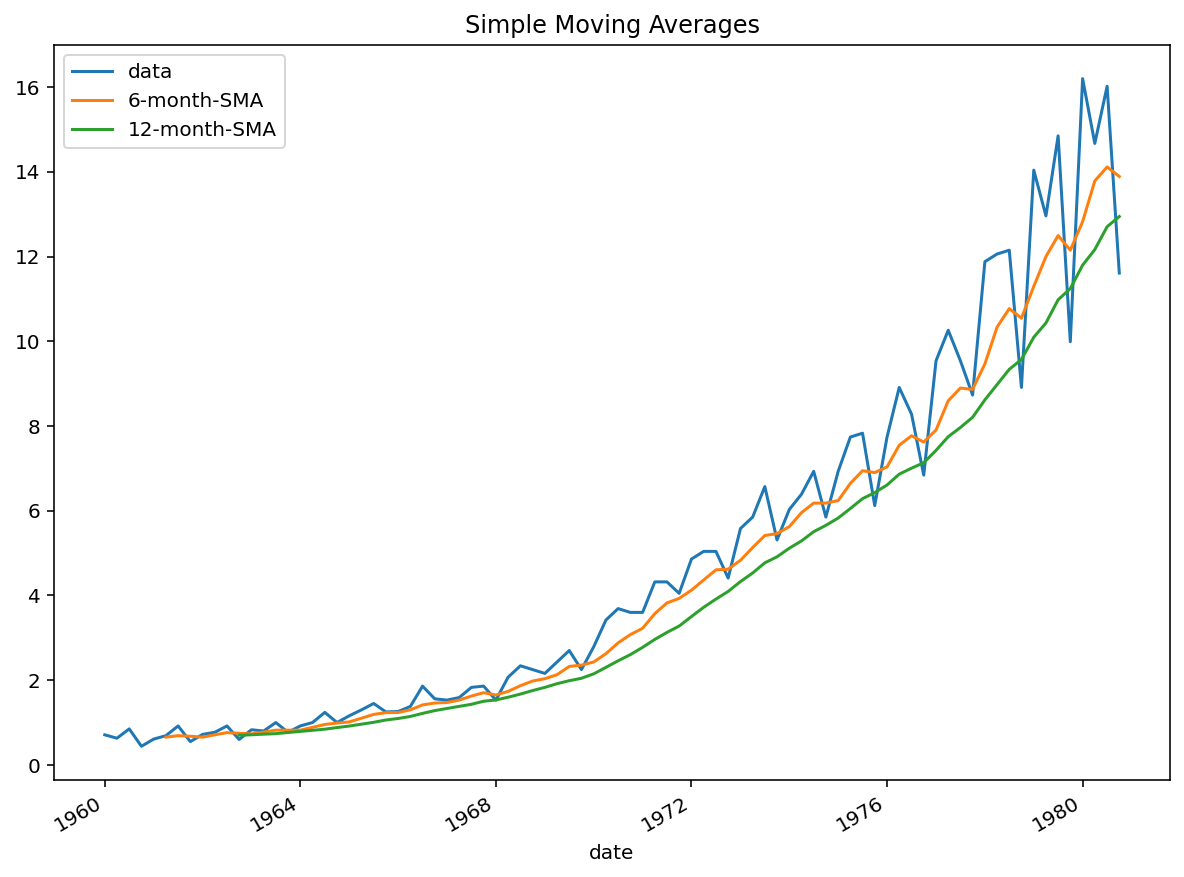

In [ ]:
from matplotlib import pyplot
fig, ax = pyplot.subplots(dpi=144)

df1.plot(title='Simple Moving Averages', ax=ax)

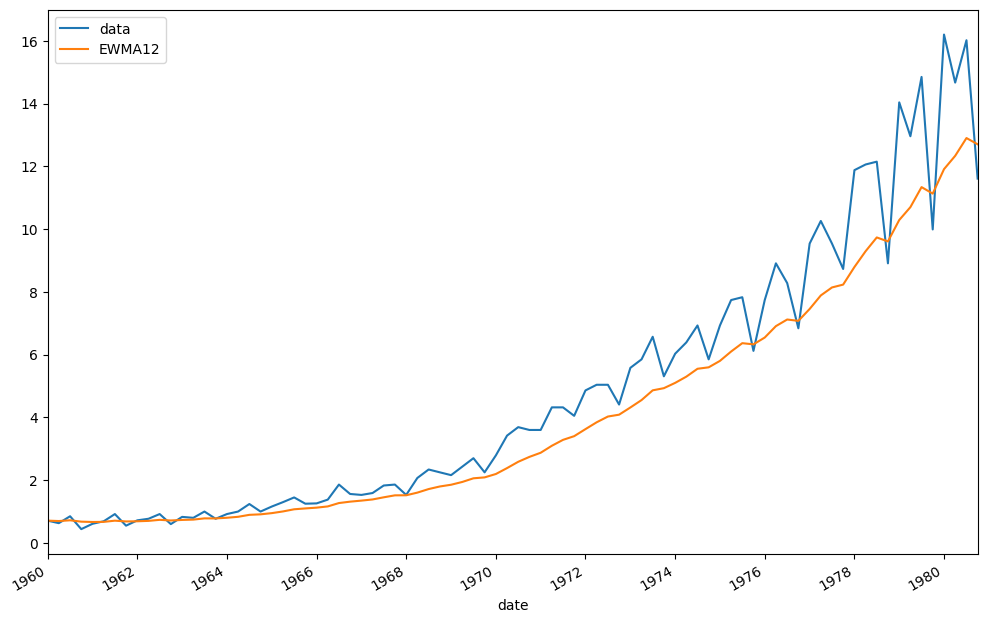

In [ ]:
df1['EWMA12'] = df1['data'].ewm(span=12,adjust=False).mean()
# Alpha value is calculated based on time interval (span)
# span = 12, alpha = 2/(span+1)
df1[['data','EWMA12']].plot(figsize=(12,8)).autoscale(axis='x',tight=True);

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=382.017, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=316.440, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=316.822, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=268.110, Time=0.12 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=119.339, Time=0.23 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=119.504, Time=0.25 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=116.566, Time=0.31 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=118.070, Time=0.42 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=318.763, Time=0.07 sec
 ARIMA

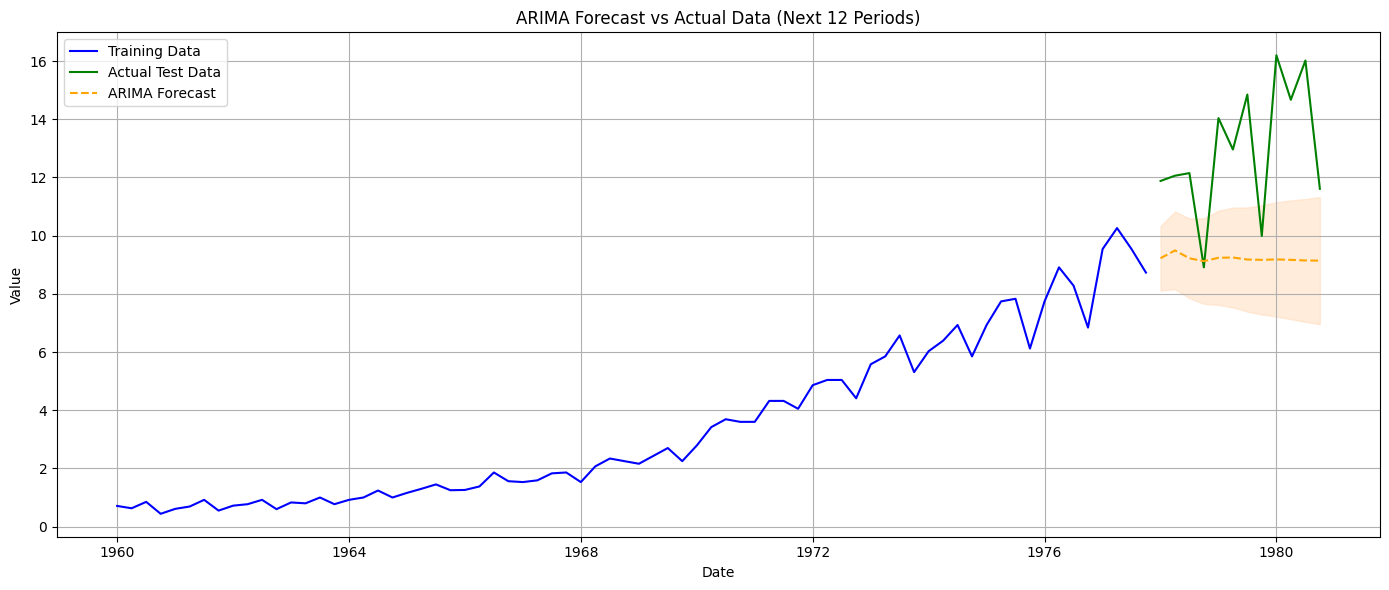

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ------------------------------------------
# Use auto_arima to get best (p,d,q) order
# ------------------------------------------
model_auto = auto_arima(diff_data,
                        start_p=0, max_p=3,
                        start_q=0, max_q=3,
                        d=0,  # since the data is already differenced
                        seasonal=False,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(model_auto.summary())

# Extract best order from auto_arima result
best_order = model_auto.order

# ------------------------------------------
# Train/Test Split
# ------------------------------------------
test_len = 12  # Forecast horizon = 12 steps (e.g., months)
train_data = df1.iloc[:-test_len]
test_data = df1.iloc[-test_len:]

# ------------------------------------------
# Train ARIMA model using best order
# ------------------------------------------
model = ARIMA(train_data['data'], order=best_order).fit()

# ------------------------------------------
# Forecast next 12 steps (24 months if monthly or 8 quarters if quarterly)
# ------------------------------------------
forecast = model.get_forecast(steps=test_len)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()
forecast_index = test_data.index

# ------------------------------------------
# Evaluation
# ------------------------------------------
y_true = test_data['data'].values
y_pred = forecast_mean.values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\nARIMA Evaluation (on last 12 periods):")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}")

# ------------------------------------------
# Visualization
# ------------------------------------------
plt.figure(figsize=(14, 6))

last_train_val = train_data['data'].iloc[-1]
last_train_date = train_data.index[-1]
forecast_series = pd.Series([last_train_val] + list(forecast_mean),
                            index=[last_train_date] + list(forecast_index))

plt.plot(train_data.index, train_data['data'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['data'], label='Actual Test Data', color='green')
plt.plot(forecast_index, forecast_mean, label='ARIMA Forecast', linestyle='--', color='orange')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='peachpuff', alpha=0.5)

plt.title('ARIMA Forecast vs Actual Data (Next 12 Periods)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


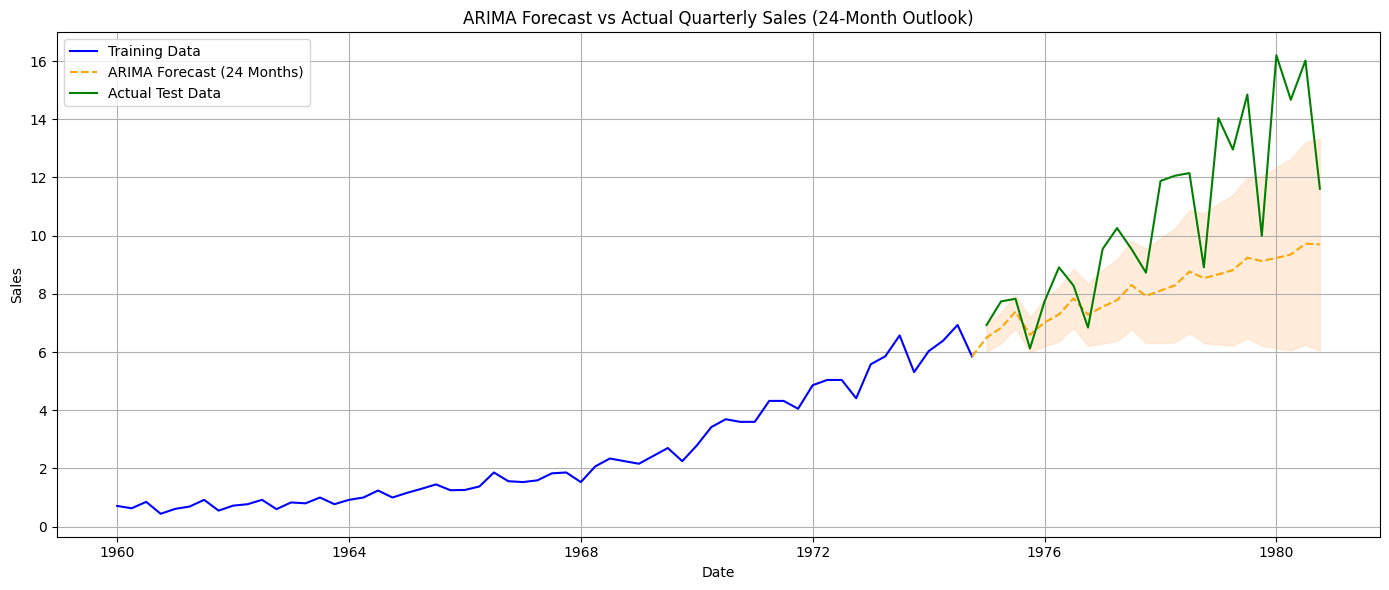

In [27]:
plt.figure(figsize=(14, 6))

# Construct continuous forecast line that begins from the last training value
last_train_val = train_data['data'].iloc[-1]
last_train_date = train_data.index[-1]
forecast_series = pd.Series([last_train_val] + list(forecast_mean),
                            index=[last_train_date] + list(forecast_index))

# Plot historical training data
plt.plot(train_data.index, train_data['data'], label='Training Data', color='blue')

# Plot forecast line starting from last train point
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast (24 Months)', color='orange', linestyle='--')

# Plot true test data
plt.plot(test_data.index, test_data['data'], label='Actual Test Data', color='green')

# Add shaded area for confidence intervals
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='peachpuff', alpha=0.5)

# Final plot adjustments
plt.title('ARIMA Forecast vs Actual Quarterly Sales (24-Month Outlook)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()